# Appendix A: PubMed Redundancy Analysis

Supporting evidence for **Final Report Section 1.1** — *The Reproducibility Crisis and Scientific Technical Debt*.

This notebook analyzes MIMIC-IV-related PubMed abstracts (2025-2026) using semantic embedding and hierarchical clustering:
1. **Load** — cached Gemini-extracted metadata (research question, methodology, data transforms, outcome, disease area)
2. **Embed** — sentence embeddings from data transforms, outcome metric, and disease area
3. **Cluster** — hierarchical agglomeration to surface natural topic groupings and quantify redundancy

In [7]:
import sys
from pathlib import Path

# Ensure project root is on sys.path so `src.*` imports work
sys.path.insert(0, str(Path.cwd().parent))

# --- Reproducibility: uncomment to re-run Gemini extraction from scratch ---
# import os, getpass
# from google import genai
# GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY") or getpass.getpass("Gemini API key: ")
# client = genai.Client(api_key=GEMINI_API_KEY)
# from src.pubmed.redundancy import fetch_abstracts, load_abstracts, extract_all, normalize

## Conclusion

The three-pass analysis above provides quantitative support for the claims in
**Final Report Section 1.1**:
- A substantial proportion of MIMIC-IV research focuses on hospital utilization metrics
- The vast majority relies on identical foundational data transformations (ICD cohort selection, vital sign extraction, lab aggregation)
- Studies cluster into redundant groups asking the same question with the same methods on the same data
- The cumulative redundant data engineering effort amounts to years of wasted human capital annually

This motivates the project's core contribution: a standardized Gold-layer
abstraction that reduces the marginal cost of clinical inquiry toward zero.

In [8]:
from src.pubmed.clustering import load_articles, embed, cluster, plot_dendrogram, plot_tsne, plot_similarity_heatmap, summary_table

df = load_articles()
emb = embed(df)
labels, Z = cluster(emb, n_clusters=10)

[LOAD] Reading /Users/kasra/Projects/MIMIC FHIR/local/pubmed_extracted_final.json
[LOAD] 1785 articles loaded


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/28 [00:00<?, ?it/s]

[EMBED] Saved (1785, 384) to /Users/kasra/Projects/MIMIC FHIR/local/pubmed_embeddings.npy
[CLUSTER] 10 clusters from 1785 articles


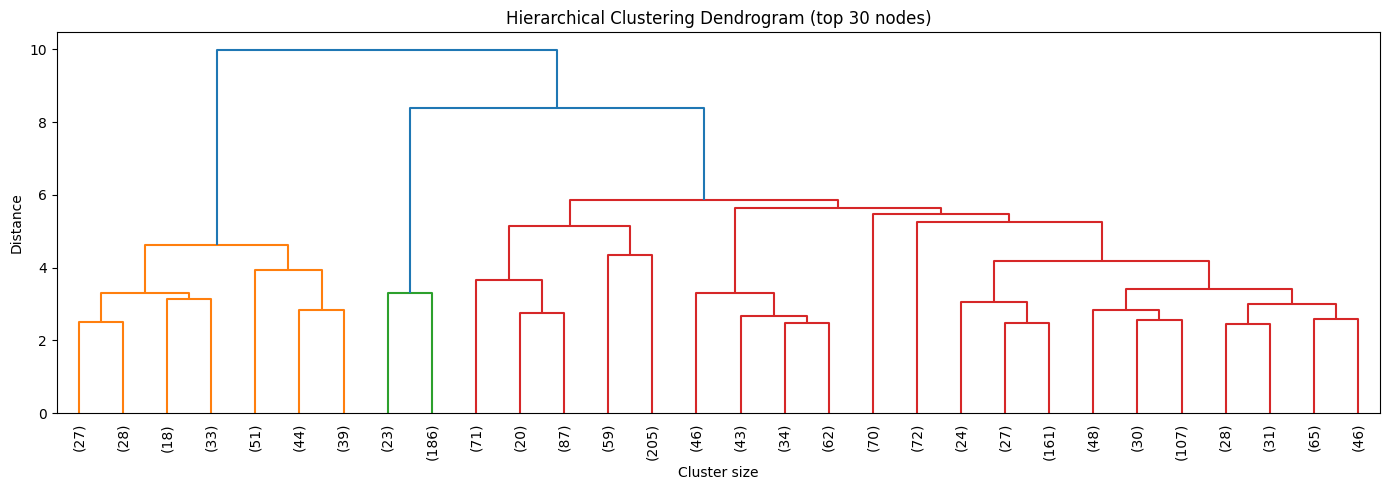

In [9]:
plot_dendrogram(Z)

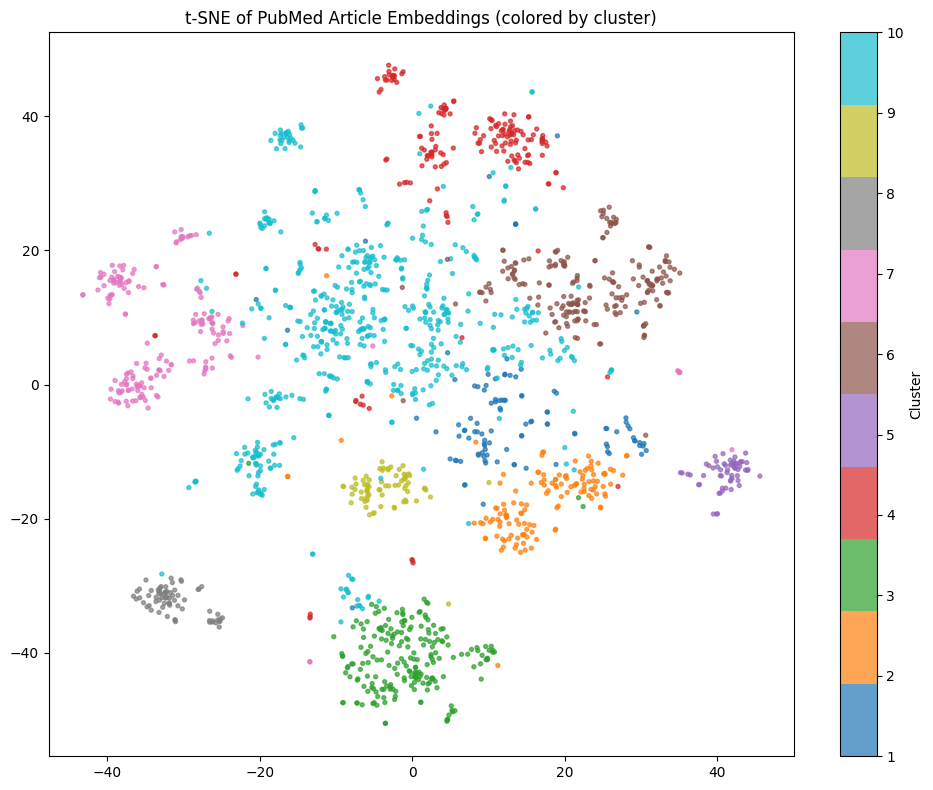

In [10]:
plot_tsne(emb, labels)

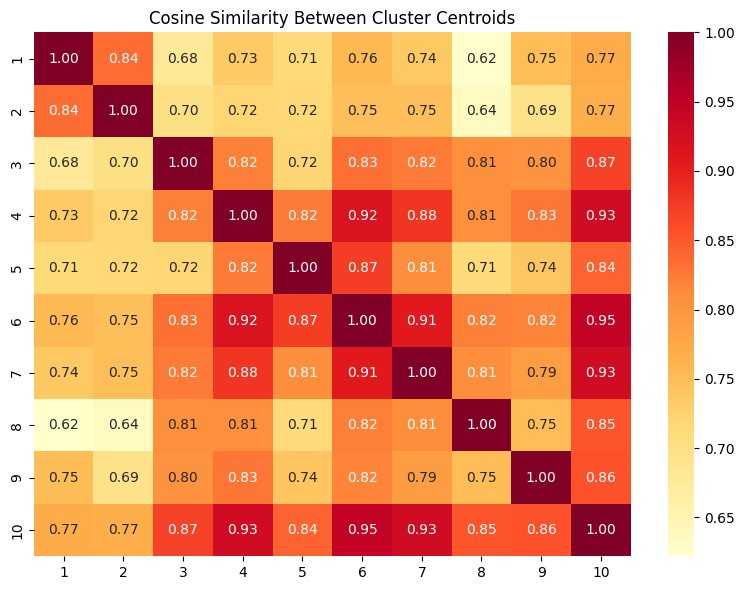

In [11]:
plot_similarity_heatmap(emb, labels)

In [12]:
summary_table(df, labels)

,cluster,n,top_diseases,top_outcomes,top_methods
9,10,567,"Sepsis, sepsis, Sepsis-associated encephalopat...","28-day mortality, 28-day all-cause mortality, ...","Group-based trajectory modeling (GBTM), Kaplan..."
2,3,209,Sepsis-associated acute kidney injury (SA-AKI)...,"28-day all-cause mortality, Acute kidney injur...","LASSO-logistic regression, nomogram, discrimin..."
5,6,205,"Heart failure (HF), heart failure, Heart failu...","30-day all-cause mortality, 28-day mortality, ...","ROC curve analysis, Cox proportional hazard re..."
6,7,185,"Chronic obstructive pulmonary disease (COPD), ...","28-day mortality, 28-day all-cause mortality, ...","Multivariate regression models, restricted cub..."
3,4,178,"Ischemic stroke, Traumatic brain injury (TBI),...","In-hospital mortality, 28-day all-cause mortal...","Cox proportional hazards model, restricted cub..."
1,2,134,"Sepsis, Critically ill patients, General criti...","28-day mortality, In-hospital mortality, ICU m...","Cox proportional hazards models, Restricted cu..."
0,1,106,"Clinical informatics, Natural Language Process...","In-hospital mortality, N/A, 28-day mortality, ...","Bibliometrics, keyword analyses, Restricted cu..."
8,9,72,"Sepsis-associated delirium, Sepsis-associated ...","Postoperative delirium (POD), Delirium inciden...","Latent class trajectory modeling (LCTM), restr..."
7,8,70,"Acute pancreatitis (AP), acute pancreatitis, A...","28-day all-cause mortality, In-hospital mortal...","Cox regression, ROC curve, Kaplan-Meier surviv..."
4,5,59,"Atrial fibrillation, atrial fibrillation, Atri...","28-day mortality, 30-day all-cause mortality, ...","Six feature selection techniques, six machine ..."


### Interpretation

The largest cluster(s) should be dominated by hospital utilization terms — mortality
prediction, readmission, length-of-stay, ICU outcomes — confirming that this is the
natural center of gravity in MIMIC-IV research. The cosine similarity heatmap quantifies
how much semantic overlap exists between clusters: high off-diagonal values indicate
studies that are asking nearly identical questions with different labels.

This validates the pipeline direction: a standardized utilization Gold layer addresses
the most redundant slice of the literature.